In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

Note: To install/configure conda,, always copy and paste code in Editor Type Script

# Setting Up Environment/venv

In [2]:
!wget -q https://repo.anaconda.com/miniconda/Miniconda3-py38_23.11.0-2-Linux-x86_64.sh -O /tmp/miniconda.sh
!bash /tmp/miniconda.sh -b -p /opt/miniconda3

PREFIX=/opt/miniconda3
Unpacking payload ...
                                                                                
Installing base environment...





Preparing transaction: done
Executing transaction: done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /opt/miniconda3


In [3]:
!/opt/miniconda3/bin/conda create -n bevfusion python=3.8 -y
!/opt/miniconda3/envs/bevfusion/bin/pip install torch==1.10.2+cu113 torchvision==0.11.3+cu113 torchaudio==0.10.2 -f https://download.pytorch.org/whl/torch_stable.html
!/opt/miniconda3/envs/bevfusion/bin/python -c "import torch; print(torch.__version__)"

Channels:
 - defaults
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /opt/miniconda3/envs/bevfusion

  added / updated specs:
    - python=3.8


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-5.1          |           52_gnu           7 KB
    ca-certificates-2026.9.25  |       h06a4308_0         107 KB
    ld_impl_linux-64-2.44      |       h9e0c5a2_3         725 KB
    libffi-3.4.8               |       h06d3fd0_3         137 KB
    libgcc-15.2.0              |       h69a1729_8         803 KB
    libgcc-ng-15.2.0           |       h166f726_8          28 KB
    libstdcxx-15.2.0           |       h39759b7_8         3.7 MB
    libstdcxx-ng-15.2.0        |       hc03a8fd_8          28 KB
    libxcb-1.17.0              |       h9b100fa_0         430 KB
    libzlib-1.3.2              |       h47b2149_0          60 KB
    ncurses-6.6   

## CUDA toolkit + gcc (needed BEFORE compiling BEVFusion's custom ops later)
Moved up here, right after torch, so everything is ready by the time we
reach `setup.py develop` — no more building mmdetection3d first and
discovering the toolkit/gcc are missing partway through.

In [4]:
!/opt/miniconda3/bin/conda install -n bevfusion -y -c nvidia/label/cuda-11.3.1 cuda-toolkit

Channels:
 - nvidia/label/cuda-11.3.1
 - defaults
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /opt/miniconda3/envs/bevfusion

  added / updated specs:
    - cuda-toolkit


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    cuda-command-line-tools-11.3.1|       h712c49d_0           2 KB  nvidia/label/cuda-11.3.1
    cuda-compiler-11.3.1       |       h712c49d_0           2 KB  nvidia/label/cuda-11.3.1
    cuda-cudart-11.3.109       |       hfb95d0c_0         1.1 MB  nvidia/label/cuda-11.3.1
    cuda-cuobjdump-11.3.122    |       hbf6ec6b_0         115 KB  nvidia/label/cuda-11.3.1
    cuda-cupti-11.3.111        |       h12ad217_0        19.5 MB  nvidia/label/cuda-11.3.1
    cuda-cuxxfilt-11.3.122     |       h4dc11a3_0          32 KB  nvidia/label/cuda-11.3.1
    cuda-gdb-11.3.109          |       h33b7820_0        39.0 MB  nvidia/label/cuda-11.3.

In [5]:
!/opt/miniconda3/bin/conda install -n bevfusion -y -c conda-forge gcc_linux-64=9 gxx_linux-64=9

Channels:
 - conda-forge
 - defaults
 - nvidia/label/cuda-11.3.1
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /opt/miniconda3/envs/bevfusion

  added / updated specs:
    - gcc_linux-64=9
    - gxx_linux-64=9


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    binutils_impl_linux-64-2.39|       he00db2b_1         4.7 MB  conda-forge
    binutils_linux-64-2.39     |      h5fc0e48_13          27 KB  conda-forge
    gcc_impl_linux-64-9.5.0    |      h99780fb_19        43.5 MB  conda-forge
    gcc_linux-64-9.5.0         |      h4258300_13          29 KB  conda-forge
    gxx_impl_linux-64-9.5.0    |      h99780fb_19        10.6 MB  conda-forge
    gxx_linux-64-9.5.0         |      h43f449f_13          28 KB  conda-forge
    kernel-headers_linux-64-5.14.0|       he073ed8_3         1.3 MB  conda-forge
    ld_impl_linux-64-2.39      |       hcc3a1bd_1  

In [6]:
!/opt/miniconda3/bin/conda install -n bevfusion -y -c conda-forge libxcrypt

Channels:
 - conda-forge
 - defaults
 - nvidia/label/cuda-11.3.1
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /opt/miniconda3/envs/bevfusion

  added / updated specs:
    - libxcrypt


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    libxcrypt-4.4.38           |       h280c20c_0         100 KB  conda-forge
    ------------------------------------------------------------
                                           Total:         100 KB

The following NEW packages will be INSTALLED:

  libxcrypt          conda-forge/linux-64::libxcrypt-4.4.38-h280c20c_0 



                                                                                
Preparing transaction: done
Verifying transaction: done
Executing transaction: done


In [7]:
# # Confirm the exact compiler binary names conda-forge installed before wiring
# # them into CC/CXX below.
!ls /opt/miniconda3/envs/bevfusion/bin/ | grep gcc

x86_64-conda_cos6-linux-gnu-gcc
x86_64-conda_cos6-linux-gnu-gcc-ar
x86_64-conda_cos6-linux-gnu-gcc-nm
x86_64-conda_cos6-linux-gnu-gcc-ranlib
x86_64-conda-linux-gnu-gcc
x86_64-conda-linux-gnu-gcc-ar
x86_64-conda-linux-gnu-gcc-nm
x86_64-conda-linux-gnu-gcc-ranlib


In [8]:
# # Persist these for the rest of the session (must be re-run after any kernel restart).
# import os
# os.environ["CUDA_HOME"] = "/opt/miniconda3/envs/bevfusion"
# os.environ["PATH"] = "/opt/miniconda3/envs/bevfusion/bin:" + os.environ["PATH"]
# # TODO: update these two filenames to exactly match the `ls | grep gcc` output above
# os.environ["CC"] = "/opt/miniconda3/envs/bevfusion/bin/x86_64-conda_cos6-linux-gnu-gcc"
# os.environ["CXX"] = "/opt/miniconda3/envs/bevfusion/bin/x86_64-conda_cos6-linux-gnu-g++"

In [9]:
# Persist these for the rest of the session
# Re-run after any kernel restart.

import os

ENV = "/opt/miniconda3/envs/bevfusion"

os.environ["CUDA_HOME"] = ENV
os.environ["PATH"] = f"{ENV}/bin:" + os.environ["PATH"]

# Conda GCC 9 / G++ 9
os.environ["CC"] = f"{ENV}/bin/x86_64-conda-linux-gnu-gcc"
os.environ["CXX"] = f"{ENV}/bin/x86_64-conda-linux-gnu-g++"
os.environ["CUDAHOSTCXX"] = os.environ["CXX"]

# System include/library paths needed during compilation
os.environ["CFLAGS"] = "-isystem /usr/include"
os.environ["CXXFLAGS"] = "-isystem /usr/include"
os.environ["LDFLAGS"] = (
    "-L/usr/lib/x86_64-linux-gnu "
    "-L/lib/x86_64-linux-gnu "
    "-L/usr/lib "
    "-L/lib"
)

In [10]:
# Both should now report versions from the env (11.3 and 9.x), not Kaggle's
# system defaults (12.8 / newer gcc).
!nvcc --version
!$CC --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2021 NVIDIA Corporation
Built on Wed_Jun__9_20:32:38_PDT_2021
Cuda compilation tools, release 11.3, V11.3.122
Build cuda_11.3.r11.3/compiler.30059648_0
x86_64-conda-linux-gnu-gcc (conda-forge gcc 9.5.0-19) 9.5.0
Copyright (C) 2019 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.



In [11]:
!/opt/miniconda3/envs/bevfusion/bin/pip install -U openmim

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 42.9 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.0/806.0 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.1/953.1 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 136.8 MB/s eta 0:00:00
  Created wheel for oss2: filename=oss2-2.17.0-py3-none-any.whl size=112372 sha256=755b5d47ce107a99497871888dc86b02fb9b64d60513f574ef2df68c11500ea1
  Stored in directory: /root/.cache/pip/wheels/84/f1/a7/a20c3f53c7dbd8a1e5aa17ab1759465203b4ee46d6b3994dd2
  Created wheel for crcmod: filename=crcmod-1.7-py3-none-any.whl size=18835 sha256=136dc828de56c3ac55945f973c2e00d96a5b512fa8c29624e12a56085abf7029
  Stored in directory: /root/.cach

In [12]:
!/opt/miniconda3/envs/bevfusion/bin/mim install mmengine

Looking in links: https://download.openmmlab.com/mmcv/dist/cu113/torch1.10.0/index.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 92.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 143.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 136.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.5 MB/s eta 0:00:00


In [13]:
!/opt/miniconda3/envs/bevfusion/bin/mim install "mmcv==2.1.0"
!/opt/miniconda3/envs/bevfusion/bin/mim install "mmdet>=3.0.0"

Looking in links: https://download.openmmlab.com/mmcv/dist/cu113/torch1.10.0/index.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 MB 12.7 MB/s eta 0:00:0000:0100:01
Looking in links: https://download.openmmlab.com/mmcv/dist/cu113/torch1.10.0/index.html
Ignoring mmcv: markers 'extra == "mim"' don't match your environment
Ignoring mmengine: markers 'extra == "mim"' don't match your environment
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 3.0 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 4.0 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 1.6 MB/s eta 0:00:00a 0:00:010m


In [14]:
!/opt/miniconda3/envs/bevfusion/bin/python -c "import mmcv, mmdet; print('mmcv', mmcv.__version__); print('mmdet', mmdet.__version__)"

mmcv 2.1.0
mmdet 3.3.0


# Setting up mmdetection3d

In [15]:
!git clone https://github.com/open-mmlab/mmdetection3d.git -b dev-1.x

Cloning into 'mmdetection3d'...
remote: Enumerating objects: 21045, done.
remote: Total 21045 (delta 0), reused 0 (delta 0), pack-reused 21045 (from 1)
Receiving objects: 100% (21045/21045), 20.61 MiB | 24.65 MiB/s, done.
Resolving deltas: 100% (14770/14770), done.


In [16]:
%cd mmdetection3d

/kaggle/working/mmdetection3d


In [17]:
!/opt/miniconda3/envs/bevfusion/bin/pip install -v -e .

Using pip 24.2 from /opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/pip (python 3.8)
Obtaining file:///kaggle/working/mmdetection3d
  Running command python setup.py egg_info
  running egg_info
  creating /tmp/pip-pip-egg-info-ehc5ewjq/mmdet3d.egg-info
  writing manifest file '/tmp/pip-pip-egg-info-ehc5ewjq/mmdet3d.egg-info/SOURCES.txt'
  writing manifest file '/tmp/pip-pip-egg-info-ehc5ewjq/mmdet3d.egg-info/SOURCES.txt'
  Preparing metadata (setup.py) ... done
  Obtaining dependency information for lyft_dataset_sdk from https://files.pythonhosted.org/packages/52/d0/1203423cd24ae9da33a66736a75ee81f7f7e487dde5041b99a66f86a444d/lyft_dataset_sdk-0.0.8-py2.py3-none-any.whl.metadata
  Link requires a different Python (3.8.20 not in: '>=3.9'): https://files.pythonhosted.org/packages/49/38/8433925423d52727d286e1e7d6a234e8f2f084cf84a1942b122231c6ef76/networkx-3.2rc0-py3-none-any.whl (from https://pypi.org/simple/networkx/) (requires-python:>=3.9)
  Link requires a different Python (

In [18]:
!/opt/miniconda3/envs/bevfusion/bin/pip install cumm-cu113
!/opt/miniconda3/envs/bevfusion/bin/pip install spconv-cu113

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.6/22.6 MB 10.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.5/70.5 MB 11.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.6/22.6 MB 4.1 MB/s eta 0:00:0000:0100:01m
  Attempting uninstall: cumm-cu113
    Found existing installation: cumm-cu113 0.5.3
    Uninstalling cumm-cu113-0.5.3:
      Successfully uninstalled cumm-cu113-0.5.3


In [19]:
!/opt/miniconda3/envs/bevfusion/bin/mim download mmdet3d --config pointpillars_hv_secfpn_8xb6-160e_kitti-3d-car --dest .

processing pointpillars_hv_secfpn_8xb6-160e_kitti-3d-car...
downloading ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.4/18.4 MiB 26.3 MB/s eta 0:00:0000:0100:01
Successfully downloaded hv_pointpillars_secfpn_6x8_160e_kitti-3d-car_20220331_134606-d42d15ed.pth to /kaggle/working/mmdetection3d
Successfully dumped pointpillars_hv_secfpn_8xb6-160e_kitti-3d-car.py to /kaggle/working/mmdetection3d


**Verifying installation**

In [20]:
!/opt/miniconda3/envs/bevfusion/bin/python demo/pcd_demo.py demo/data/kitti/000008.bin pointpillars_hv_secfpn_8xb6-160e_kitti-3d-car.py hv_pointpillars_secfpn_6x8_160e_kitti-3d-car_20220331_134606-d42d15ed.pth

/kaggle/working/mmdetection3d/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Loads checkpoint by local backend from path: hv_pointpillars_secfpn_6x8_160e_kitti-3d-car_20220331_134606-d42d15ed.pth
10/07 19:04:16 - mmengine - WARNING - Failed to search registry with scope "mmdet3d" in the "function" registry tree. As a workaround, the current "function" registry in "mmengine" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet3d" is a correct scope, or whether the registry is initialized.
/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '
/opt/miniconda3/envs

# Setting up BEV-Fusion
CUDA toolkit and gcc were already installed and wired up earlier, so this
should now compile cleanly on the first try.

In [21]:
%cd projects/BEVFusion

/kaggle/working/mmdetection3d/projects/BEVFusion


In [22]:
!ls
# !cat README.md

bevfusion  configs  demo  README.md  setup.py


In [23]:
%cd ../..

/kaggle/working/mmdetection3d


In [24]:
ENV = "/opt/miniconda3/envs/bevfusion"
ROOT = "/kaggle/working/mmdetection3d"
BEV = f"{ROOT}/projects/BEVFusion"

%cd {BEV}

!rm -rf build dist
!rm -rf *.egg-info
!find {BEV}/bevfusion -type f -name "*.so" -delete
!find {BEV}/bevfusion -type f -name "*.o" -delete

print("Old BEVFusion build artifacts removed.")

/kaggle/working/mmdetection3d/projects/BEVFusion
Old BEVFusion build artifacts removed.


In [25]:
ENV = "/opt/miniconda3/envs/bevfusion"
ROOT = "/kaggle/working/mmdetection3d"

%cd {ROOT}

!{ENV}/bin/python projects/BEVFusion/setup.py build_ext --inplace

/kaggle/working/mmdetection3d
running build_ext
creating /kaggle/working/mmdetection3d/build
creating /kaggle/working/mmdetection3d/build/temp.linux-x86_64-3.8
creating /kaggle/working/mmdetection3d/build/temp.linux-x86_64-3.8/projects
creating /kaggle/working/mmdetection3d/build/temp.linux-x86_64-3.8/projects/BEVFusion
creating /kaggle/working/mmdetection3d/build/temp.linux-x86_64-3.8/projects/BEVFusion/bevfusion
creating /kaggle/working/mmdetection3d/build/temp.linux-x86_64-3.8/projects/BEVFusion/bevfusion/ops
creating /kaggle/working/mmdetection3d/build/temp.linux-x86_64-3.8/projects/BEVFusion/bevfusion/ops/bev_pool
creating /kaggle/working/mmdetection3d/build/temp.linux-x86_64-3.8/projects/BEVFusion/bevfusion/ops/bev_pool/src
Emitting ninja build file /kaggle/working/mmdetection3d/build/temp.linux-x86_64-3.8/build.ninja...
Compiling objects...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)
[1/2] /opt/miniconda3/envs

In [26]:
# !/opt/miniconda3/bin/conda install -n bevfusion -y -c conda-forge libxcrypt

In [27]:
!{ENV}/bin/x86_64-conda-linux-gnu-gcc --version
!{ENV}/bin/x86_64-conda-linux-gnu-g++ --version

x86_64-conda-linux-gnu-gcc (conda-forge gcc 9.5.0-19) 9.5.0
Copyright (C) 2019 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

x86_64-conda-linux-gnu-g++ (conda-forge gcc 9.5.0-19) 9.5.0
Copyright (C) 2019 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.



In [28]:
!test -x {ENV}/bin/x86_64-conda-linux-gnu-gcc && echo "GCC found"
!test -x {ENV}/bin/x86_64-conda-linux-gnu-g++ && echo "G++ found"

GCC found
G++ found


In [29]:
print("CUDA_HOME:", os.environ["CUDA_HOME"])
print("CC:", os.environ["CC"])
print("CXX:", os.environ["CXX"])
print("CUDAHOSTCXX:", os.environ["CUDAHOSTCXX"])
print("CFLAGS:", os.environ["CFLAGS"])
print("CXXFLAGS:", os.environ["CXXFLAGS"])
print("LDFLAGS:", os.environ["LDFLAGS"])

CUDA_HOME: /opt/miniconda3/envs/bevfusion
CC: /opt/miniconda3/envs/bevfusion/bin/x86_64-conda-linux-gnu-gcc
CXX: /opt/miniconda3/envs/bevfusion/bin/x86_64-conda-linux-gnu-g++
CUDAHOSTCXX: /opt/miniconda3/envs/bevfusion/bin/x86_64-conda-linux-gnu-g++
CFLAGS: -isystem /usr/include
CXXFLAGS: -isystem /usr/include
LDFLAGS: -L/usr/lib/x86_64-linux-gnu -L/lib/x86_64-linux-gnu -L/usr/lib -L/lib


In [30]:
!/opt/miniconda3/envs/bevfusion/bin/python -c "import torch; print('PyTorch:', torch.__version__); print('CUDA:', torch.version.cuda); print('CUDA available:', torch.cuda.is_available())"

PyTorch: 1.10.2+cu113
CUDA: 11.3
CUDA available: True


# BEV Inference

In [31]:
!find /kaggle/working/mmdetection3d/demo/data/nuscenes \
  -maxdepth 3 -type f | sort

/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_BACK__1532402927637525.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_BACK_LEFT__1532402927647423.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_BACK_RIGHT__1532402927627893.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_FRONT_LEFT__1532402927604844.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_FRONT_RIGHT__1532402927620339.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800.pkl


In [32]:
import pickle

pkl_path = (
    "/kaggle/working/mmdetection3d/demo/data/nuscenes/"
    "n015-2018-07-24-11-22-45+0800.pkl"
)

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

print("Type:", type(data))

if isinstance(data, dict):
    print("Keys:", data.keys())
    for key, value in data.items():
        print(f"{key}: {type(value)}")
else:
    print("Length:", len(data))
    if len(data) > 0:
        print("First item type:", type(data[0]))
        print("First item:", data[0])

Type: <class 'dict'>
Keys: dict_keys(['metainfo', 'data_list'])
metainfo: <class 'dict'>
data_list: <class 'list'>


In [33]:
!wget -O /kaggle/working/bevfusion_lidar-cam.pth \
"https://download.openmmlab.com/mmdetection3d/v1.1.0_models/bevfusion/bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d-5239b1af.pth"

--2026-10-07 19:06:01--  https://download.openmmlab.com/mmdetection3d/v1.1.0_models/bevfusion/bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d-5239b1af.pth
Resolving download.openmmlab.com (download.openmmlab.com)... 192.169.122.174, 192.169.122.148, 192.169.122.175, ...
Connecting to download.openmmlab.com (download.openmmlab.com)|192.169.122.174|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 167113973 (159M) [application/octet-stream]
Saving to: ‘/kaggle/working/bevfusion_lidar-cam.pth’

/kaggle/working/bev 100%[===================>] 159.37M  26.8MB/s    in 6.1s    

2026-10-07 19:06:07 (25.9 MB/s) - ‘/kaggle/working/bevfusion_lidar-cam.pth’ saved [167113973/167113973]



In [34]:
ENV = "/opt/miniconda3/envs/bevfusion"
ROOT = "/kaggle/working/mmdetection3d"
OUT = "/kaggle/working/bevfusion_result.png"

!PYTHONPATH={ROOT}:{ROOT}/projects/BEVFusion \
{ENV}/bin/python \
{ROOT}/projects/BEVFusion/demo/multi_modality_demo.py \
{ROOT}/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin \
{ROOT}/demo/data/nuscenes/ \
{ROOT}/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800.pkl \
{ROOT}/projects/BEVFusion/configs/bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d.py \
/kaggle/working/bevfusion_lidar-cam.pth \
--cam-type all \
--score-thr 0.2 \
--out-dir {OUT}

/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/mmdet/models/task_modules/builder.py:17: UserWarning: ``build_sampler`` would be deprecated soon, please use ``mmdet.registry.TASK_UTILS.build()`` 
  warnings.warn('``build_sampler`` would be deprecated soon, please use '
/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/mmdet/models/task_modules/builder.py:39: UserWarning: ``build_assigner`` would be deprecated soon, please use ``mmdet.registry.TASK_UTILS.build()`` 
  warnings.warn('``build_assigner`` would be deprecated soon, please use '
/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/torch/functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
10/07 19:06:17 - mmengine - INFO - Loads checkpoint by http backend from path: https://github.com/SwinTr

Exists: True


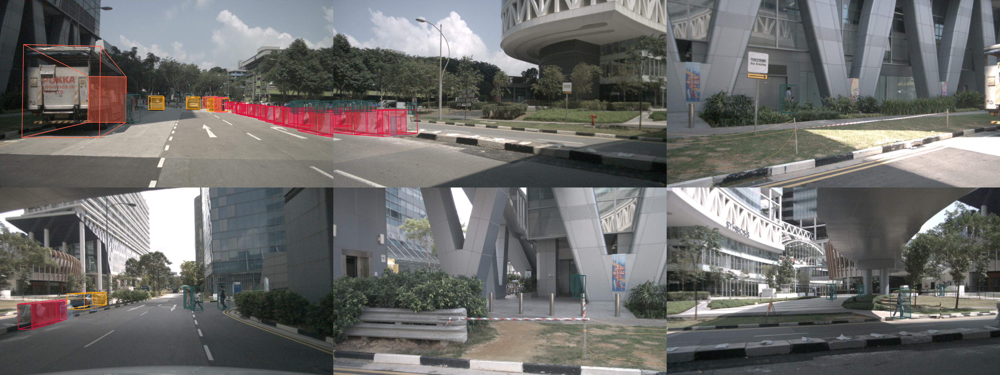

In [35]:
import os
from IPython.display import display, Image

print("Exists:", os.path.exists(OUT))

if os.path.exists(OUT):
    display(Image(filename=OUT))

In [36]:
! /opt/miniconda3/envs/bevfusion/bin/python \
/kaggle/working/mmdetection3d/projects/BEVFusion/demo/multi_modality_demo.py \
--help

! grep -nE "show|out|save|visual|draw" \
/kaggle/working/mmdetection3d/projects/BEVFusion/demo/multi_modality_demo.py

usage: multi_modality_demo.py [-h] [--device DEVICE] [--cam-type CAM_TYPE]
                              [--score-thr SCORE_THR] [--out-dir OUT_DIR]
                              [--show] [--snapshot]
                              pcd img ann config checkpoint

positional arguments:
  pcd                   Point cloud file
  img                   image file
  ann                   ann file
  config                Config file
  checkpoint            Checkpoint file

optional arguments:
  -h, --help            show this help message and exit
  --device DEVICE       Device used for inference
  --cam-type CAM_TYPE   choose camera type to inference
  --score-thr SCORE_THR
                        bbox score threshold
  --out-dir OUT_DIR     dir to save results
  --show                show online visualization results
  --snapshot            whether to save online visualization results
27:        '--out-dir', type=str, default='demo', help='dir to save results')
29:        '--show',
31:      

# Inference on nuscenes mini data

In [37]:
# ============================================================
# Step 1: nuScenes-mini dataset
# ============================================================

MINI_ROOT = "/kaggle/input/datasets/aadimator/nuscenes-mini"

import os

print("nuScenes-mini path:", MINI_ROOT)
print("Exists:", os.path.exists(MINI_ROOT))

print("\nContents:")
for item in os.listdir(MINI_ROOT):
    print(" -", item)

nuScenes-mini path: /kaggle/input/datasets/aadimator/nuscenes-mini
Exists: True

Contents:
 - samples
 - .v1.0-mini.txt
 - maps
 - v1.0-mini
 - sweeps


In [38]:
# ============================================================
# Step 2: Verify nuScenes-mini metadata
# ============================================================

NUSC_VERSION = f"{MINI_ROOT}/v1.0-mini"

print("Metadata path:", NUSC_VERSION)
print("\nMetadata files:")

for filename in sorted(os.listdir(NUSC_VERSION)):
    print(" -", filename)

Metadata path: /kaggle/input/datasets/aadimator/nuscenes-mini/v1.0-mini

Metadata files:
 - attribute.json
 - calibrated_sensor.json
 - category.json
 - ego_pose.json
 - instance.json
 - log.json
 - map.json
 - sample.json
 - sample_annotation.json
 - sample_data.json
 - scene.json
 - sensor.json
 - visibility.json


In [39]:
# ============================================================
# Step 3a: Install nuScenes dev-kit
# ============================================================

!{ENV}/bin/pip install nuscenes-devkit

In [40]:
# ============================================================
# Step 3b: Verify nuScenes in BEVFusion environment
# ============================================================

!{ENV}/bin/python -c "from nuscenes.nuscenes import NuScenes; print('nuScenes dev-kit import: OK')"

nuScenes dev-kit import: OK


In [41]:
# ============================================================
# Step 3c: Initialize nuScenes-mini
# ============================================================

!{ENV}/bin/python -c "from nuscenes.nuscenes import NuScenes; nusc=NuScenes(version='v1.0-mini', dataroot='{MINI_ROOT}', verbose=True); print('Samples:', len(nusc.sample)); print('Scenes:', len(nusc.scene)); print('Sample data:', len(nusc.sample_data))"

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.856 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
Samples: 404
Scenes: 10
Sample data: 31206


In [42]:
# ============================================================
# Step 4: Inspect one nuScenes-mini sample
# ============================================================

script = f'''
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(
    version="v1.0-mini",
    dataroot="{MINI_ROOT}",
    verbose=False
)

sample = nusc.sample[0]

print("Sample token:", sample["token"])
print("Timestamp:", sample["timestamp"])
print("Scene token:", sample["scene_token"])

print()
print("Sensors:")

for sensor_name, sample_data_token in sample["data"].items():
    sd = nusc.get("sample_data", sample_data_token)
    print(sensor_name, "->", sd["filename"])
'''

with open("/kaggle/working/inspect_nuscenes.py", "w") as f:
    f.write(script)

!{ENV}/bin/python /kaggle/working/inspect_nuscenes.py

Sample token: ca9a282c9e77460f8360f564131a8af5
Timestamp: 1532402927647951
Scene token: cc8c0bf57f984915a77078b10eb33198

Sensors:
RADAR_FRONT -> samples/RADAR_FRONT/n015-2018-07-24-11-22-45+0800__RADAR_FRONT__1532402927664178.pcd
RADAR_FRONT_LEFT -> samples/RADAR_FRONT_LEFT/n015-2018-07-24-11-22-45+0800__RADAR_FRONT_LEFT__1532402927652686.pcd
RADAR_FRONT_RIGHT -> samples/RADAR_FRONT_RIGHT/n015-2018-07-24-11-22-45+0800__RADAR_FRONT_RIGHT__1532402927639817.pcd
RADAR_BACK_LEFT -> samples/RADAR_BACK_LEFT/n015-2018-07-24-11-22-45+0800__RADAR_BACK_LEFT__1532402927668356.pcd
RADAR_BACK_RIGHT -> samples/RADAR_BACK_RIGHT/n015-2018-07-24-11-22-45+0800__RADAR_BACK_RIGHT__1532402927635538.pcd
LIDAR_TOP -> samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin
CAM_FRONT -> samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
CAM_FRONT_RIGHT -> samples/CAM_FRONT_RIGHT/n015-2018-07-24-11-22-45+0800__CAM_FRONT_RIGHT__1532402927620339.jpg
CAM_B

In [43]:
# ============================================================
# Step 5: Verify nuScenes sensor files
# ============================================================

script = f'''
import os
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(
    version="v1.0-mini",
    dataroot="{MINI_ROOT}",
    verbose=False
)

sample = nusc.sample[0]

required_sensors = [
    "LIDAR_TOP",
    "CAM_FRONT",
    "CAM_FRONT_LEFT",
    "CAM_FRONT_RIGHT",
    "CAM_BACK",
    "CAM_BACK_LEFT",
    "CAM_BACK_RIGHT",
]

print("Sensor files:")
print()

for sensor_name in required_sensors:
    sample_data_token = sample["data"][sensor_name]
    sd = nusc.get("sample_data", sample_data_token)

    filepath = os.path.join("{MINI_ROOT}", sd["filename"])

    print(sensor_name)
    print("  File:", filepath)
    print("  Exists:", os.path.exists(filepath))
    print()
'''

with open("/kaggle/working/verify_nuscenes_files.py", "w") as f:
    f.write(script)

!{ENV}/bin/python /kaggle/working/verify_nuscenes_files.py

Sensor files:

LIDAR_TOP
  File: /kaggle/input/datasets/aadimator/nuscenes-mini/samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin
  Exists: True

CAM_FRONT
  File: /kaggle/input/datasets/aadimator/nuscenes-mini/samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
  Exists: True

CAM_FRONT_LEFT
  File: /kaggle/input/datasets/aadimator/nuscenes-mini/samples/CAM_FRONT_LEFT/n015-2018-07-24-11-22-45+0800__CAM_FRONT_LEFT__1532402927604844.jpg
  Exists: True

CAM_FRONT_RIGHT
  File: /kaggle/input/datasets/aadimator/nuscenes-mini/samples/CAM_FRONT_RIGHT/n015-2018-07-24-11-22-45+0800__CAM_FRONT_RIGHT__1532402927620339.jpg
  Exists: True

CAM_BACK
  File: /kaggle/input/datasets/aadimator/nuscenes-mini/samples/CAM_BACK/n015-2018-07-24-11-22-45+0800__CAM_BACK__1532402927637525.jpg
  Exists: True

CAM_BACK_LEFT
  File: /kaggle/input/datasets/aadimator/nuscenes-mini/samples/CAM_BACK_LEFT/n015-2018-07-24-11-22-45+0800__CAM_BACK_LEFT__1532

In [44]:
# ============================================================
# Step 6: Inspect sensor calibration
# ============================================================

script = f'''
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(
    version="v1.0-mini",
    dataroot="{MINI_ROOT}",
    verbose=False
)

sample = nusc.sample[0]

for sensor_name in [
    "LIDAR_TOP",
    "CAM_FRONT",
    "CAM_FRONT_LEFT",
    "CAM_FRONT_RIGHT",
    "CAM_BACK",
    "CAM_BACK_LEFT",
    "CAM_BACK_RIGHT",
]:

    sample_data_token = sample["data"][sensor_name]
    sd = nusc.get("sample_data", sample_data_token)

    calibrated_sensor = nusc.get(
        "calibrated_sensor",
        sd["calibrated_sensor_token"]
    )

    print()
    print("=" * 60)
    print(sensor_name)
    print("=" * 60)

    print("Sensor modality:", sd["is_key_frame"])
    print("Translation:", calibrated_sensor["translation"])
    print("Rotation:", calibrated_sensor["rotation"])

    if "camera_intrinsic" in calibrated_sensor:
        print("Camera intrinsic:")
        print(calibrated_sensor["camera_intrinsic"])
'''

with open("/kaggle/working/inspect_calibration.py", "w") as f:
    f.write(script)

!{ENV}/bin/python /kaggle/working/inspect_calibration.py


LIDAR_TOP
Sensor modality: True
Translation: [0.943713, 0.0, 1.84023]
Rotation: [0.7077955119163518, -0.006492242056004365, 0.010646214713995808, -0.7063073142877817]
Camera intrinsic:
[]

CAM_FRONT
Sensor modality: True
Translation: [1.70079118954, 0.0159456324149, 1.51095763913]
Rotation: [0.4998015430569128, -0.5030316162024876, 0.4997798114386805, -0.49737083824542755]
Camera intrinsic:
[[1266.417203046554, 0.0, 816.2670197447984], [0.0, 1266.417203046554, 491.50706579294757], [0.0, 0.0, 1.0]]

CAM_FRONT_LEFT
Sensor modality: True
Translation: [1.52387798135, 0.494631336551, 1.50932822144]
Rotation: [0.6757265034669446, -0.6736266522251881, 0.21214015046209478, -0.21122827103904068]
Camera intrinsic:
[[1272.5979470598488, 0.0, 826.6154927353808], [0.0, 1272.5979470598488, 479.75165386361925], [0.0, 0.0, 1.0]]

CAM_FRONT_RIGHT
Sensor modality: True
Translation: [1.5508477543, -0.493404796419, 1.49574800619]
Rotation: [0.2060347966337182, -0.2026940577919598, 0.6824507824531167, -0.

## inspecting bevfusion datastructure for inference

In [45]:
# ============================================================
# Step 7: Inspect bundled BEVFusion sample metadata
# ============================================================

import pickle

PKL_PATH = (
    "/kaggle/working/mmdetection3d/demo/data/nuscenes/"
    "n015-2018-07-24-11-22-45+0800.pkl"
)

with open(PKL_PATH, "rb") as f:
    data = pickle.load(f)

print("Type:", type(data))

if isinstance(data, dict):
    print("\nTop-level keys:")
    for key in data.keys():
        print(" -", key)

    print("\nValue types:")
    for key, value in data.items():
        print(f" - {key}: {type(value)}")

else:
    print("Length:", len(data))

    if len(data) > 0:
        print("First item type:", type(data[0]))
        print("First item:")
        print(data[0])

Type: <class 'dict'>

Top-level keys:
 - metainfo
 - data_list

Value types:
 - metainfo: <class 'dict'>
 - data_list: <class 'list'>


In [46]:
# ============================================================
# Step 8: Inspect one bundled BEVFusion sample
# ============================================================

sample = data["data_list"][0]

print("Sample keys:")
for key in sample.keys():
    print(" -", key)

print("\nFull sample structure:")
print(sample)

Sample keys:
 - sample_idx
 - token
 - timestamp
 - ego2global
 - images
 - lidar_points
 - instances
 - cam_instances

Full sample structure:
{'sample_idx': 0, 'token': 'ca9a282c9e77460f8360f564131a8af5', 'timestamp': 1532402927.647951, 'ego2global': [[-0.345552921295166, 0.9382579922676086, 0.016282515600323677, 411.3039245605469], [-0.9383381009101868, -0.34528031945228577, -0.01740977168083191, 1180.890380859375], [-0.010712824761867523, -0.021294502541422844, 0.9997158646583557, 0.0], [0.0, 0.0, 0.0, 1.0]], 'images': {'CAM_FRONT': {'img_path': 'n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg', 'cam2img': [[1266.417203046554, 0.0, 816.2670197447984], [0.0, 1266.417203046554, 491.50706579294757], [0.0, 0.0, 1.0]], 'cam2ego': [[0.005684778559952974, -0.005636667832732201, 0.9999679327011108, 1.7007912397384644], [-0.9999834895133972, -0.0008371152798645198, 0.0056801484897732735, 0.01594563201069832], [0.000805071322247386, -0.9999837875366211, -0.005641333758831024, 1

In [47]:
# ============================================================
# Step 9: Inspect paths and LiDAR structure
# ============================================================

sample = data["data_list"][0]

print("=== LiDAR ===")
print(sample["lidar_points"])

print("\n=== Cameras ===")
for cam_name, cam in sample["images"].items():
    print(f"\n{cam_name}")
    print("  img_path:", cam["img_path"])
    print("  sample_data_token:", cam["sample_data_token"])

=== LiDAR ===
{'num_pts_feats': 5, 'lidar_path': 'n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin', 'lidar2ego': [[0.0020332718268036842, 0.9997040629386902, 0.024241721257567406, 0.9437130093574524], [-0.9999805092811584, 0.0021756570786237717, -0.00584863917902112, 0.0], [-0.005899650044739246, -0.02422935888171196, 0.9996890425682068, 1.8402299880981445], [0.0, 0.0, 0.0, 1.0]]}

=== Cameras ===

CAM_FRONT
  img_path: n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
  sample_data_token: e3d495d4ac534d54b321f50006683844

CAM_FRONT_RIGHT
  img_path: n015-2018-07-24-11-22-45+0800__CAM_FRONT_RIGHT__1532402927620339.jpg
  sample_data_token: aac7867ebf4f446395d29fbd60b63b3b

CAM_FRONT_LEFT
  img_path: n015-2018-07-24-11-22-45+0800__CAM_FRONT_LEFT__1532402927604844.jpg
  sample_data_token: fe5422747a7d4268a4b07fc396707b23

CAM_BACK
  img_path: n015-2018-07-24-11-22-45+0800__CAM_BACK__1532402927637525.jpg
  sample_data_token: 03bea5763f0f4722933508d5999c5fd8


In [48]:
# ============================================================
# Step 10: Verify bundled BEVFusion sample vs real nuScenes-mini
# ============================================================

import os

sample = data["data_list"][0]

print("=== LiDAR ===")

lidar_file = sample["lidar_points"]["lidar_path"]
lidar_path = os.path.join(MINI_ROOT, "samples", "LIDAR_TOP", lidar_file)

print("File:", lidar_file)
print("Path:", lidar_path)
print("Exists:", os.path.exists(lidar_path))

print("\n=== Cameras ===")

for cam_name, cam in sample["images"].items():
    img_file = cam["img_path"]
    img_path = os.path.join(MINI_ROOT, "samples", cam_name, img_file)

    print(f"{cam_name}:")
    print("  File:", img_file)
    print("  Exists:", os.path.exists(img_path))

=== LiDAR ===
File: n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin
Path: /kaggle/input/datasets/aadimator/nuscenes-mini/samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin
Exists: True

=== Cameras ===
CAM_FRONT:
  File: n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
  Exists: True
CAM_FRONT_RIGHT:
  File: n015-2018-07-24-11-22-45+0800__CAM_FRONT_RIGHT__1532402927620339.jpg
  Exists: True
CAM_FRONT_LEFT:
  File: n015-2018-07-24-11-22-45+0800__CAM_FRONT_LEFT__1532402927604844.jpg
  Exists: True
CAM_BACK:
  File: n015-2018-07-24-11-22-45+0800__CAM_BACK__1532402927637525.jpg
  Exists: True
CAM_BACK_LEFT:
  File: n015-2018-07-24-11-22-45+0800__CAM_BACK_LEFT__1532402927647423.jpg
  Exists: True
CAM_BACK_RIGHT:
  File: n015-2018-07-24-11-22-45+0800__CAM_BACK_RIGHT__1532402927627893.jpg
  Exists: True


## Create a BEVFusion-format .pkl for nuScenes-mini

In [49]:
# ============================================================
# Step 11: Create BEVFusion-format metadata for nuScenes-mini
# ============================================================

import pickle
import os

sample = data["data_list"][0]

# Make a copy so we don't modify the original bundled metadata
mini_sample = sample.copy()

# ------------------------------------------------------------
# Update LiDAR path to actual nuScenes-mini location
# ------------------------------------------------------------

lidar_file = sample["lidar_points"]["lidar_path"]

mini_sample["lidar_points"] = sample["lidar_points"].copy()
mini_sample["lidar_points"]["lidar_path"] = os.path.join(
    MINI_ROOT,
    "samples",
    "LIDAR_TOP",
    lidar_file
)

# ------------------------------------------------------------
# Update camera paths to actual nuScenes-mini locations
# ------------------------------------------------------------

mini_sample["images"] = {}

for cam_name, cam in sample["images"].items():

    cam_copy = cam.copy()

    cam_copy["img_path"] = os.path.join(
        MINI_ROOT,
        "samples",
        cam_name,
        cam["img_path"]
    )

    mini_sample["images"][cam_name] = cam_copy

# ------------------------------------------------------------
# Create BEVFusion data structure
# ------------------------------------------------------------

mini_data = {
    "metainfo": data["metainfo"],
    "data_list": [mini_sample]
}

MINI_PKL = "/kaggle/working/nuscenes_mini_bevfusion.pkl"

with open(MINI_PKL, "wb") as f:
    pickle.dump(mini_data, f)

print("Created:", MINI_PKL)
print("LiDAR:", mini_sample["lidar_points"]["lidar_path"])

print("\nCamera paths:")
for cam_name, cam in mini_sample["images"].items():
    print(cam_name, "->", cam["img_path"])

Created: /kaggle/working/nuscenes_mini_bevfusion.pkl
LiDAR: /kaggle/input/datasets/aadimator/nuscenes-mini/samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin

Camera paths:
CAM_FRONT -> /kaggle/input/datasets/aadimator/nuscenes-mini/samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
CAM_FRONT_RIGHT -> /kaggle/input/datasets/aadimator/nuscenes-mini/samples/CAM_FRONT_RIGHT/n015-2018-07-24-11-22-45+0800__CAM_FRONT_RIGHT__1532402927620339.jpg
CAM_FRONT_LEFT -> /kaggle/input/datasets/aadimator/nuscenes-mini/samples/CAM_FRONT_LEFT/n015-2018-07-24-11-22-45+0800__CAM_FRONT_LEFT__1532402927604844.jpg
CAM_BACK -> /kaggle/input/datasets/aadimator/nuscenes-mini/samples/CAM_BACK/n015-2018-07-24-11-22-45+0800__CAM_BACK__1532402927637525.jpg
CAM_BACK_LEFT -> /kaggle/input/datasets/aadimator/nuscenes-mini/samples/CAM_BACK_LEFT/n015-2018-07-24-11-22-45+0800__CAM_BACK_LEFT__1532402927647423.jpg
CAM_BACK_RIGHT -> /kaggle/input/datasets/aadim

In [50]:
# ============================================================
# Step 12: Validate mini BEVFusion metadata
# ============================================================

import pickle
import os

with open(MINI_PKL, "rb") as f:
    mini_data = pickle.load(f)

sample = mini_data["data_list"][0]

print("PKL loaded: OK")
print("Samples:", len(mini_data["data_list"]))
print("Sample token:", sample["token"])

lidar = sample["lidar_points"]["lidar_path"]

print("\nLiDAR exists:", os.path.exists(lidar))
print("LiDAR:", lidar)

print("\nCameras:")

for name, cam in sample["images"].items():
    path = cam["img_path"]
    print(name + ":", os.path.exists(path))

PKL loaded: OK
Samples: 1
Sample token: ca9a282c9e77460f8360f564131a8af5

LiDAR exists: True
LiDAR: /kaggle/input/datasets/aadimator/nuscenes-mini/samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin

Cameras:
CAM_FRONT: True
CAM_FRONT_RIGHT: True
CAM_FRONT_LEFT: True
CAM_BACK: True
CAM_BACK_LEFT: True
CAM_BACK_RIGHT: True


In [51]:
# ============================================================
# Step 13: Inspect BEVFusion demo input expectations
# ============================================================

import os

DEMO = f"{ROOT}/projects/BEVFusion/demo/multi_modality_demo.py"

print("Demo exists:", os.path.exists(DEMO))
print("Demo path:", DEMO)

!sed -n '1,220p' {DEMO}

Demo exists: True
Demo path: /kaggle/working/mmdetection3d/projects/BEVFusion/demo/multi_modality_demo.py
# Copyright (c) OpenMMLab. All rights reserved.
from argparse import ArgumentParser

import mmcv

from mmdet3d.apis import inference_multi_modality_detector, init_model
from mmdet3d.registry import VISUALIZERS


def parse_args():
    parser = ArgumentParser()
    parser.add_argument('pcd', help='Point cloud file')
    parser.add_argument('img', help='image file')
    parser.add_argument('ann', help='ann file')
    parser.add_argument('config', help='Config file')
    parser.add_argument('checkpoint', help='Checkpoint file')
    parser.add_argument(
        '--device', default='cuda:0', help='Device used for inference')
    parser.add_argument(
        '--cam-type',
        type=str,
        default='CAM_FRONT',
        help='choose camera type to inference')
    parser.add_argument(
        '--score-thr', type=float, default=0.0, help='bbox score threshold')
    parser.add_argument

In [52]:
# ============================================================
# Step 14: Inspect inference_multi_modality_detector
# ============================================================

script = """
import inspect
from mmdet3d.apis import inference_multi_modality_detector

print(inspect.getsource(inference_multi_modality_detector))
"""

script_path = "/kaggle/working/inspect_inference_api.py"

with open(script_path, "w") as f:
    f.write(script)

!{ENV}/bin/python {script_path}

def inference_multi_modality_detector(model: nn.Module,
                                      pcds: Union[str, Sequence[str]],
                                      imgs: Union[str, Sequence[str]],
                                      ann_file: Union[str, Sequence[str]],
                                      cam_type: str = 'CAM2'):
    """Inference point cloud with the multi-modality detector. Now we only
    support multi-modality detector for KITTI and SUNRGBD datasets since the
    multi-view image loading is not supported yet in this inference function.

    Args:
        model (nn.Module): The loaded detector.
        pcds (str, Sequence[str]):
            Either point cloud files or loaded point cloud.
        imgs (str, Sequence[str]):
           Either image files or loaded images.
        ann_file (str, Sequence[str]): Annotation files.
        cam_type (str): Image of Camera chose to infer. When detector only uses
            single-view image, we need to specify a camera v

In [53]:
DEMO_IMG_DIR = f"{ROOT}/demo/data/nuscenes"

!find {DEMO_IMG_DIR} -maxdepth 1 -type f | head -20

/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_BACK_LEFT__1532402927647423.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800.pkl
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_BACK_RIGHT__1532402927627893.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_FRONT_RIGHT__1532402927620339.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_FRONT_LEFT__1532402927604844.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_BACK__1532402927637525.jpg


## Create a mini demo directory

### BEV Fusion for single mini data

In [54]:
# ============================================================
# Step 16: Create BEVFusion-compatible nuScenes-mini directory
# ============================================================

import os

MINI_DEMO_DIR = "/kaggle/working/nuscenes_mini_demo"

os.makedirs(MINI_DEMO_DIR, exist_ok=True)

sample = data["data_list"][0]

# ------------------------------------------------------------
# Symlink LiDAR
# ------------------------------------------------------------

lidar_src = os.path.join(
    MINI_ROOT,
    "samples",
    "LIDAR_TOP",
    os.path.basename(sample["lidar_points"]["lidar_path"])
)

lidar_dst = os.path.join(
    MINI_DEMO_DIR,
    os.path.basename(lidar_src)
)

if not os.path.exists(lidar_dst):
    os.symlink(lidar_src, lidar_dst)

# ------------------------------------------------------------
# Symlink six camera images
# ------------------------------------------------------------

for cam_name, cam in sample["images"].items():

    img_src = os.path.join(
        MINI_ROOT,
        "samples",
        cam_name,
        os.path.basename(cam["img_path"])
    )

    img_dst = os.path.join(
        MINI_DEMO_DIR,
        os.path.basename(img_src)
    )

    if not os.path.exists(img_dst):
        os.symlink(img_src, img_dst)

print("Created:", MINI_DEMO_DIR)

print("\nFiles:")
for f in sorted(os.listdir(MINI_DEMO_DIR)):
    print(" -", f)

Created: /kaggle/working/nuscenes_mini_demo

Files:
 - n015-2018-07-24-11-22-45+0800__CAM_BACK_LEFT__1532402927647423.jpg
 - n015-2018-07-24-11-22-45+0800__CAM_BACK_RIGHT__1532402927627893.jpg
 - n015-2018-07-24-11-22-45+0800__CAM_BACK__1532402927637525.jpg
 - n015-2018-07-24-11-22-45+0800__CAM_FRONT_LEFT__1532402927604844.jpg
 - n015-2018-07-24-11-22-45+0800__CAM_FRONT_RIGHT__1532402927620339.jpg
 - n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
 - n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin


In [55]:
# ============================================================
# Step 17: Create BEVFusion-compatible nuScenes-mini PKL
# ============================================================

import pickle
import copy
import os

sample = copy.deepcopy(data["data_list"][0])

# Keep only filenames, matching the bundled BEVFusion demo format
sample["lidar_points"]["lidar_path"] = os.path.basename(
    sample["lidar_points"]["lidar_path"]
)

for cam_name, cam in sample["images"].items():
    cam["img_path"] = os.path.basename(cam["img_path"])

# Build metadata
mini_demo_data = {
    "metainfo": data["metainfo"],
    "data_list": [sample]
}

MINI_DEMO_PKL = os.path.join(
    MINI_DEMO_DIR,
    "n015-2018-07-24-11-22-45+0800.pkl"
)

with open(MINI_DEMO_PKL, "wb") as f:
    pickle.dump(mini_demo_data, f)

print("Created:", MINI_DEMO_PKL)

print("\nLiDAR:")
print(sample["lidar_points"]["lidar_path"])

print("\nCameras:")
for cam_name, cam in sample["images"].items():
    print(cam_name, "->", cam["img_path"])

Created: /kaggle/working/nuscenes_mini_demo/n015-2018-07-24-11-22-45+0800.pkl

LiDAR:
n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin

Cameras:
CAM_FRONT -> n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
CAM_FRONT_RIGHT -> n015-2018-07-24-11-22-45+0800__CAM_FRONT_RIGHT__1532402927620339.jpg
CAM_FRONT_LEFT -> n015-2018-07-24-11-22-45+0800__CAM_FRONT_LEFT__1532402927604844.jpg
CAM_BACK -> n015-2018-07-24-11-22-45+0800__CAM_BACK__1532402927637525.jpg
CAM_BACK_LEFT -> n015-2018-07-24-11-22-45+0800__CAM_BACK_LEFT__1532402927647423.jpg
CAM_BACK_RIGHT -> n015-2018-07-24-11-22-45+0800__CAM_BACK_RIGHT__1532402927627893.jpg


In [56]:
# ============================================================
# Step 19: Create PKL using BEVFusion environment
# ============================================================

script = f"""
import pickle
import os
import copy

MINI_ROOT = "{MINI_ROOT}"
OUT_DIR = "{MINI_DEMO_DIR}"
OUT_PKL = "{MINI_DEMO_DIR}/n015-2018-07-24-11-22-45+0800.pkl"

# ------------------------------------------------------------
# Load the original bundled BEVFusion metadata
# using the BEVFusion environment itself
# ------------------------------------------------------------

BUNDLED_PKL = "{PKL_PATH}"

with open(BUNDLED_PKL, "rb") as f:
    bundled = pickle.load(f)

sample = copy.deepcopy(bundled["data_list"][0])

# ------------------------------------------------------------
# Keep only filenames
# ------------------------------------------------------------

sample["lidar_points"]["lidar_path"] = os.path.basename(
    sample["lidar_points"]["lidar_path"]
)

for cam_name, cam in sample["images"].items():
    cam["img_path"] = os.path.basename(cam["img_path"])

# ------------------------------------------------------------
# Write BEVFusion-compatible PKL
# ------------------------------------------------------------

output = {{
    "metainfo": bundled["metainfo"],
    "data_list": [sample]
}}

with open(OUT_PKL, "wb") as f:
    pickle.dump(output, f, protocol=2)

print("Created:", OUT_PKL)
print("Sample token:", sample["token"])
print("Num samples:", len(output["data_list"]))
"""

script_path = "/kaggle/working/create_bevfusion_pkl.py"

with open(script_path, "w") as f:
    f.write(script)

!{ENV}/bin/python {script_path}

Created: /kaggle/working/nuscenes_mini_demo/n015-2018-07-24-11-22-45+0800.pkl
Sample token: ca9a282c9e77460f8360f564131a8af5
Num samples: 1


## Run BEVFusion on the real nuScenes-mini sample

In [57]:
# ============================================================
# Step 18: BEVFusion inference on nuScenes-mini
# ============================================================

PCD = os.path.join(
    MINI_DEMO_DIR,
    "n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin"
)

IMG_DIR = MINI_DEMO_DIR
ANN = MINI_DEMO_PKL

CONFIG = (
    f"{ROOT}/projects/BEVFusion/configs/"
    "bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d.py"
)

CHECKPOINT = "/kaggle/working/bevfusion_lidar-cam.pth"

OUT_DIR = "/kaggle/working/bevfusion_mini_output"

!mkdir -p {OUT_DIR}

!PYTHONPATH={ROOT}:{ROOT}/projects/BEVFusion \
{ENV}/bin/python \
{ROOT}/projects/BEVFusion/demo/multi_modality_demo.py \
{PCD} \
{IMG_DIR}/ \
{ANN} \
{CONFIG} \
{CHECKPOINT} \
--cam-type all \
--score-thr 0.2 \
--out-dir {OUT_DIR}

/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/mmdet/models/task_modules/builder.py:17: UserWarning: ``build_sampler`` would be deprecated soon, please use ``mmdet.registry.TASK_UTILS.build()`` 
  warnings.warn('``build_sampler`` would be deprecated soon, please use '
/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/mmdet/models/task_modules/builder.py:39: UserWarning: ``build_assigner`` would be deprecated soon, please use ``mmdet.registry.TASK_UTILS.build()`` 
  warnings.warn('``build_assigner`` would be deprecated soon, please use '
/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/torch/functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
10/07 19:07:00 - mmengine - INFO - Loads checkpoint by http backend from path: https://github.com/SwinTr

In [58]:
# ============================================================
# Step 20: Inspect BEVFusion output
# ============================================================

import os

print("Output directory:", OUT_DIR)

for root, dirs, files in os.walk(OUT_DIR):
    for file in files:
        path = os.path.join(root, file)
        print(path, "->", os.path.getsize(path), "bytes")

Output directory: /kaggle/working/bevfusion_mini_output


In [59]:
# ============================================================
# Step 20: Save BEVFusion visualization as an image
# ============================================================

OUT_IMAGE = "/kaggle/working/bevfusion_mini_result.jpg"

!PYTHONPATH={ROOT}:{ROOT}/projects/BEVFusion \
{ENV}/bin/python \
{ROOT}/projects/BEVFusion/demo/multi_modality_demo.py \
{PCD} \
{IMG_DIR}/ \
{ANN} \
{CONFIG} \
{CHECKPOINT} \
--cam-type all \
--score-thr 0.2 \
--out-dir {OUT_IMAGE}

/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/mmdet/models/task_modules/builder.py:17: UserWarning: ``build_sampler`` would be deprecated soon, please use ``mmdet.registry.TASK_UTILS.build()`` 
  warnings.warn('``build_sampler`` would be deprecated soon, please use '
/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/mmdet/models/task_modules/builder.py:39: UserWarning: ``build_assigner`` would be deprecated soon, please use ``mmdet.registry.TASK_UTILS.build()`` 
  warnings.warn('``build_assigner`` would be deprecated soon, please use '
/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/torch/functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
10/07 19:07:21 - mmengine - INFO - Loads checkpoint by http backend from path: https://github.com/SwinTr

## BEV Fusion inference on all mini data

In [69]:
# ============================================================
# Step 21: BEVFusion inference on ALL nuScenes-mini samples
#          Model loaded ONCE
#          Save RAW predictions + sample metadata
# ============================================================

import os

ENV = "/opt/miniconda3/envs/bevfusion"
ROOT = "/kaggle/working/mmdetection3d"

MINI_ROOT = "/kaggle/input/datasets/aadimator/nuscenes-mini"

# Temporary directory used by BEVFusion
MINI_DEMO_DIR = "/kaggle/working/nuscenes_mini_demo"

# Raw prediction output
OUTPUT_DIR = "/kaggle/working/bevfusion_predictions"

# Clean old predictions
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(MINI_DEMO_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

CONFIG = (
    f"{ROOT}/projects/BEVFusion/configs/"
    "bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d.py"
)

CHECKPOINT = "/kaggle/working/bevfusion_lidar-cam.pth"

os.makedirs(MINI_DEMO_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# Python script executed inside BEVFusion environment
# ============================================================

script = r"""
import os
import shutil
import pickle
import numpy as np

from pyquaternion import Quaternion
from nuscenes.nuscenes import NuScenes

from mmdet3d.apis import init_model

from projects.BEVFusion.demo.multi_modality_demo import (
    inference_multi_modality_detector
)


# ============================================================
# Configuration
# ============================================================

MINI_ROOT = "__MINI_ROOT__"
DEMO_DIR = "__DEMO_DIR__"
OUTPUT_DIR = "__OUTPUT_DIR__"

CONFIG = "__CONFIG__"
CHECKPOINT = "__CHECKPOINT__"

CAMERAS = [
    "CAM_FRONT",
    "CAM_FRONT_RIGHT",
    "CAM_BACK_RIGHT",
    "CAM_BACK",
    "CAM_BACK_LEFT",
    "CAM_FRONT_LEFT"
]


# ============================================================
# Load nuScenes-mini
# ============================================================

nusc = NuScenes(
    version="v1.0-mini",
    dataroot=MINI_ROOT,
    verbose=False
)

NUM_SAMPLES = len(nusc.sample)

print()
print("=" * 70)
print("nuScenes-mini samples:", NUM_SAMPLES)
print("=" * 70)


# ============================================================
# Load BEVFusion model ONCE
# ============================================================

print()
print("Loading BEVFusion model ONCE...")
print()

model = init_model(
    CONFIG,
    CHECKPOINT,
    device="cuda:0"
)

model.eval()

print()
print("BEVFusion model loaded.")
print()


# ============================================================
# Process all samples
# ============================================================

for sample_index in range(NUM_SAMPLES):

    print()
    print("=" * 70)
    print(
        f"Sample {sample_index + 1} / {NUM_SAMPLES}"
    )
    print("=" * 70)

    sample = nusc.sample[sample_index]

    sample_token = sample["token"]

    print("Sample index:", sample_index)
    print("Sample token:", sample_token)


    # ========================================================
    # Clean temporary directory
    # ========================================================

    for filename in os.listdir(DEMO_DIR):

        path = os.path.join(
            DEMO_DIR,
            filename
        )

        if os.path.islink(path) or os.path.isfile(path):

            os.remove(path)

        elif os.path.isdir(path):

            shutil.rmtree(path)


    # ========================================================
    # LIDAR
    # ========================================================

    lidar_token = sample["data"]["LIDAR_TOP"]

    lidar_sd = nusc.get(
        "sample_data",
        lidar_token
    )

    lidar_source = os.path.join(
        MINI_ROOT,
        lidar_sd["filename"]
    )

    lidar_filename = os.path.basename(
        lidar_sd["filename"]
    )

    lidar_destination = os.path.join(
        DEMO_DIR,
        lidar_filename
    )

    os.symlink(
        lidar_source,
        lidar_destination
    )


    # ========================================================
    # LiDAR calibration
    # ========================================================

    lidar_calib = nusc.get(
        "calibrated_sensor",
        lidar_sd["calibrated_sensor_token"]
    )

    lidar2ego = np.eye(
        4,
        dtype=np.float32
    )

    lidar2ego[:3, :3] = Quaternion(
        lidar_calib["rotation"]
    ).rotation_matrix

    lidar2ego[:3, 3] = np.array(
        lidar_calib["translation"],
        dtype=np.float32
    )


    # ========================================================
    # Camera information
    # ========================================================

    images = {}

    for cam_name in CAMERAS:

        cam_token = sample["data"][cam_name]

        cam_sd = nusc.get(
            "sample_data",
            cam_token
        )

        cam_source = os.path.join(
            MINI_ROOT,
            cam_sd["filename"]
        )

        cam_filename = os.path.basename(
            cam_sd["filename"]
        )

        cam_destination = os.path.join(
            DEMO_DIR,
            cam_filename
        )

        os.symlink(
            cam_source,
            cam_destination
        )


        # ----------------------------------------------------
        # Camera calibration
        # ----------------------------------------------------

        cam_calib = nusc.get(
            "calibrated_sensor",
            cam_sd["calibrated_sensor_token"]
        )

        cam2ego = np.eye(
            4,
            dtype=np.float32
        )

        cam2ego[:3, :3] = Quaternion(
            cam_calib["rotation"]
        ).rotation_matrix

        cam2ego[:3, 3] = np.array(
            cam_calib["translation"],
            dtype=np.float32
        )

        ego2cam = np.linalg.inv(
            cam2ego
        )

        lidar2cam = (
            ego2cam @ lidar2ego
        )


        images[cam_name] = {

            "img_path": cam_filename,

            "cam2img": np.array(
                cam_calib["camera_intrinsic"],
                dtype=np.float32
            ).tolist(),

            "cam2ego": cam2ego.tolist(),

            "sample_data_token": cam_token,

            "timestamp": cam_sd["timestamp"] / 1e6,

            "lidar2cam": lidar2cam.tolist()
        }


    # ========================================================
    # Ego pose
    # ========================================================

    ego_pose = nusc.get(
        "ego_pose",
        lidar_sd["ego_pose_token"]
    )

    ego2global = np.eye(
        4,
        dtype=np.float32
    )

    ego2global[:3, :3] = Quaternion(
        ego_pose["rotation"]
    ).rotation_matrix

    ego2global[:3, 3] = np.array(
        ego_pose["translation"],
        dtype=np.float32
    )


    # ========================================================
    # Create BEVFusion-compatible sample
    # ========================================================

    bev_sample = {

        "sample_idx": sample_index,

        "token": sample_token,

        "timestamp": sample["timestamp"] / 1e6,

        "ego2global": ego2global.tolist(),

        "images": images,

        "lidar_points": {

            "num_pts_feats": 5,

            "lidar_path": lidar_filename,

            "lidar2ego": lidar2ego.tolist()
        },

        "instances": [],

        "cam_instances": []
    }


    # ========================================================
    # Temporary PKL
    # ========================================================

    pkl_path = os.path.join(
        DEMO_DIR,
        f"sample_{sample_index:04d}.pkl"
    )

    output = {

        "metainfo": {

            "categories": {

                "car": 0,
                "truck": 1,
                "construction_vehicle": 2,
                "bus": 3,
                "trailer": 4,
                "barrier": 5,
                "motorcycle": 6,
                "bicycle": 7,
                "pedestrian": 8,
                "traffic_cone": 9
            }
        },

        "data_list": [
            bev_sample
        ]
    }


    with open(
        pkl_path,
        "wb"
    ) as f:

        pickle.dump(
            output,
            f,
            protocol=2
        )


    # ========================================================
    # BEVFusion inference
    #
    # IMPORTANT:
    # SAME model is reused for every sample.
    # ========================================================

    result, data = inference_multi_modality_detector(
        model,
        lidar_destination,
        DEMO_DIR,
        pkl_path,
        "all"
    )


    # ========================================================
    # Save RAW prediction + sample metadata
    # ========================================================

    output_path = os.path.join(
        OUTPUT_DIR,
        f"sample_{sample_index:04d}.pkl"
    )

    prediction = {

        "sample_index": sample_index,

        "sample_token": sample_token,

        "result": result
    }


    with open(
        output_path,
        "wb"
    ) as f:

        pickle.dump(
            prediction,
            f,
            protocol=2
        )


    print(
        "Prediction saved:",
        output_path
    )


# ============================================================
# Finished
# ============================================================

print()
print("=" * 70)
print("ALL SAMPLES COMPLETE")
print("=" * 70)

print(
    "Total samples:",
    NUM_SAMPLES
)

print(
    "Predictions:",
    OUTPUT_DIR
)
"""


# ============================================================
# Inject paths WITHOUT using an f-string
# ============================================================

script = script.replace(
    "__MINI_ROOT__",
    MINI_ROOT
)

script = script.replace(
    "__DEMO_DIR__",
    MINI_DEMO_DIR
)

script = script.replace(
    "__OUTPUT_DIR__",
    OUTPUT_DIR
)

script = script.replace(
    "__CONFIG__",
    CONFIG
)

script = script.replace(
    "__CHECKPOINT__",
    CHECKPOINT
)


# ============================================================
# Save script
# ============================================================

script_path = (
    "/kaggle/working/"
    "bevfusion_all_samples_once.py"
)

with open(
    script_path,
    "w"
) as f:

    f.write(script)


# ============================================================
# Run inside BEVFusion environment
# ============================================================

!PYTHONPATH={ROOT}:{ROOT}/projects/BEVFusion \
{ENV}/bin/python {script_path}


nuScenes-mini samples: 404

Loading BEVFusion model ONCE...

/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/mmdet/models/task_modules/builder.py:17: UserWarning: ``build_sampler`` would be deprecated soon, please use ``mmdet.registry.TASK_UTILS.build()`` 
  warnings.warn('``build_sampler`` would be deprecated soon, please use '
/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/mmdet/models/task_modules/builder.py:39: UserWarning: ``build_assigner`` would be deprecated soon, please use ``mmdet.registry.TASK_UTILS.build()`` 
  warnings.warn('``build_assigner`` would be deprecated soon, please use '
/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/torch/functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
10/07 19:37:55 - mmengine - INFO - Loads c

In [60]:
# # ============================================================
# # Step 21: BEVFusion inference on ALL nuScenes-mini samples ***WITHOUT TOKEN
# #          Model loaded ONCE
# #          Save RAW predictions only
# # ============================================================

# import os

# ENV = "/opt/miniconda3/envs/bevfusion"
# ROOT = "/kaggle/working/mmdetection3d"

# MINI_ROOT = "/kaggle/input/datasets/aadimator/nuscenes-mini"

# # Temporary directory used by BEVFusion
# MINI_DEMO_DIR = "/kaggle/working/nuscenes_mini_demo"

# # Raw prediction output
# OUTPUT_DIR = "/kaggle/working/bevfusion_predictions"

# CONFIG = (
#     f"{ROOT}/projects/BEVFusion/configs/"
#     "bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d.py"
# )

# CHECKPOINT = "/kaggle/working/bevfusion_lidar-cam.pth"

# os.makedirs(MINI_DEMO_DIR, exist_ok=True)
# os.makedirs(OUTPUT_DIR, exist_ok=True)


# # ============================================================
# # Python script executed inside BEVFusion environment
# # ============================================================

# script = r"""
# import os
# import shutil
# import pickle
# import numpy as np

# from pyquaternion import Quaternion
# from nuscenes.nuscenes import NuScenes

# from mmdet3d.apis import init_model

# from projects.BEVFusion.demo.multi_modality_demo import (
#     inference_multi_modality_detector
# )


# # ============================================================
# # Configuration
# # ============================================================

# MINI_ROOT = "__MINI_ROOT__"
# DEMO_DIR = "__DEMO_DIR__"
# OUTPUT_DIR = "__OUTPUT_DIR__"

# CONFIG = "__CONFIG__"
# CHECKPOINT = "__CHECKPOINT__"

# CAMERAS = [
#     "CAM_FRONT",
#     "CAM_FRONT_RIGHT",
#     "CAM_BACK_RIGHT",
#     "CAM_BACK",
#     "CAM_BACK_LEFT",
#     "CAM_FRONT_LEFT"
# ]


# # ============================================================
# # Load nuScenes-mini
# # ============================================================

# nusc = NuScenes(
#     version="v1.0-mini",
#     dataroot=MINI_ROOT,
#     verbose=False
# )

# NUM_SAMPLES = len(nusc.sample)

# print()
# print("=" * 70)
# print("nuScenes-mini samples:", NUM_SAMPLES)
# print("=" * 70)


# # ============================================================
# # Load BEVFusion model ONCE
# # ============================================================

# print()
# print("Loading BEVFusion model ONCE...")
# print()

# model = init_model(
#     CONFIG,
#     CHECKPOINT,
#     device="cuda:0"
# )

# model.eval()

# print()
# print("BEVFusion model loaded.")
# print()


# # ============================================================
# # Process all samples
# # ============================================================

# for sample_index in range(NUM_SAMPLES):

#     print()
#     print("=" * 70)
#     print(
#         f"Sample {sample_index + 1} / {NUM_SAMPLES}"
#     )
#     print("=" * 70)

#     sample = nusc.sample[sample_index]

#     sample_token = sample["token"]

#     print("Token:", sample_token)


#     # ========================================================
#     # Clean temporary directory
#     # ========================================================

#     for filename in os.listdir(DEMO_DIR):

#         path = os.path.join(
#             DEMO_DIR,
#             filename
#         )

#         if os.path.islink(path) or os.path.isfile(path):

#             os.remove(path)

#         elif os.path.isdir(path):

#             shutil.rmtree(path)


#     # ========================================================
#     # LIDAR
#     # ========================================================

#     lidar_token = sample["data"]["LIDAR_TOP"]

#     lidar_sd = nusc.get(
#         "sample_data",
#         lidar_token
#     )

#     lidar_source = os.path.join(
#         MINI_ROOT,
#         lidar_sd["filename"]
#     )

#     lidar_filename = os.path.basename(
#         lidar_sd["filename"]
#     )

#     lidar_destination = os.path.join(
#         DEMO_DIR,
#         lidar_filename
#     )

#     os.symlink(
#         lidar_source,
#         lidar_destination
#     )


#     # ========================================================
#     # LiDAR calibration
#     # ========================================================

#     lidar_calib = nusc.get(
#         "calibrated_sensor",
#         lidar_sd["calibrated_sensor_token"]
#     )

#     lidar2ego = np.eye(
#         4,
#         dtype=np.float32
#     )

#     lidar2ego[:3, :3] = Quaternion(
#         lidar_calib["rotation"]
#     ).rotation_matrix

#     lidar2ego[:3, 3] = np.array(
#         lidar_calib["translation"],
#         dtype=np.float32
#     )


#     # ========================================================
#     # Camera information
#     # ========================================================

#     images = {}

#     for cam_name in CAMERAS:

#         cam_token = sample["data"][cam_name]

#         cam_sd = nusc.get(
#             "sample_data",
#             cam_token
#         )

#         cam_source = os.path.join(
#             MINI_ROOT,
#             cam_sd["filename"]
#         )

#         cam_filename = os.path.basename(
#             cam_sd["filename"]
#         )

#         cam_destination = os.path.join(
#             DEMO_DIR,
#             cam_filename
#         )

#         os.symlink(
#             cam_source,
#             cam_destination
#         )


#         # ----------------------------------------------------
#         # Camera calibration
#         # ----------------------------------------------------

#         cam_calib = nusc.get(
#             "calibrated_sensor",
#             cam_sd["calibrated_sensor_token"]
#         )

#         cam2ego = np.eye(
#             4,
#             dtype=np.float32
#         )

#         cam2ego[:3, :3] = Quaternion(
#             cam_calib["rotation"]
#         ).rotation_matrix

#         cam2ego[:3, 3] = np.array(
#             cam_calib["translation"],
#             dtype=np.float32
#         )

#         ego2cam = np.linalg.inv(
#             cam2ego
#         )

#         lidar2cam = (
#             ego2cam @ lidar2ego
#         )


#         images[cam_name] = {

#             "img_path": cam_filename,

#             "cam2img": np.array(
#                 cam_calib["camera_intrinsic"],
#                 dtype=np.float32
#             ).tolist(),

#             "cam2ego": cam2ego.tolist(),

#             "sample_data_token": cam_token,

#             "timestamp": cam_sd["timestamp"] / 1e6,

#             "lidar2cam": lidar2cam.tolist()
#         }


#     # ========================================================
#     # Ego pose
#     # ========================================================

#     ego_pose = nusc.get(
#         "ego_pose",
#         lidar_sd["ego_pose_token"]
#     )

#     ego2global = np.eye(
#         4,
#         dtype=np.float32
#     )

#     ego2global[:3, :3] = Quaternion(
#         ego_pose["rotation"]
#     ).rotation_matrix

#     ego2global[:3, 3] = np.array(
#         ego_pose["translation"],
#         dtype=np.float32
#     )


#     # ========================================================
#     # Create BEVFusion-compatible sample
#     # ========================================================

#     bev_sample = {

#         "sample_idx": sample_index,

#         "token": sample_token,

#         "timestamp": sample["timestamp"] / 1e6,

#         "ego2global": ego2global.tolist(),

#         "images": images,

#         "lidar_points": {

#             "num_pts_feats": 5,

#             "lidar_path": lidar_filename,

#             "lidar2ego": lidar2ego.tolist()
#         },

#         "instances": [],

#         "cam_instances": []
#     }


#     # ========================================================
#     # Temporary PKL
#     # ========================================================

#     pkl_path = os.path.join(
#         DEMO_DIR,
#         f"sample_{sample_index:04d}.pkl"
#     )

#     output = {

#         "metainfo": {

#             "categories": {

#                 "car": 0,
#                 "truck": 1,
#                 "construction_vehicle": 2,
#                 "bus": 3,
#                 "trailer": 4,
#                 "barrier": 5,
#                 "motorcycle": 6,
#                 "bicycle": 7,
#                 "pedestrian": 8,
#                 "traffic_cone": 9
#             }
#         },

#         "data_list": [
#             bev_sample
#         ]
#     }


#     with open(
#         pkl_path,
#         "wb"
#     ) as f:

#         pickle.dump(
#             output,
#             f,
#             protocol=2
#         )


#     # ========================================================
#     # BEVFusion inference
#     #
#     # IMPORTANT:
#     # SAME model is reused for every sample.
#     # ========================================================

#     result, data = inference_multi_modality_detector(
#         model,
#         lidar_destination,
#         DEMO_DIR,
#         pkl_path,
#         "all"
#     )


#     # ========================================================
#     # Save RAW prediction
#     # ========================================================

#     output_path = os.path.join(
#         OUTPUT_DIR,
#         f"sample_{sample_index:04d}.pkl"
#     )

#     with open(
#         output_path,
#         "wb"
#     ) as f:

#         pickle.dump(
#             result,
#             f,
#             protocol=2
#         )


#     print(
#         "Prediction saved:",
#         output_path
#     )


# # ============================================================
# # Finished
# # ============================================================

# print()
# print("=" * 70)
# print("ALL SAMPLES COMPLETE")
# print("=" * 70)

# print(
#     "Total samples:",
#     NUM_SAMPLES
# )

# print(
#     "Predictions:",
#     OUTPUT_DIR
# )
# """


# # ============================================================
# # Inject paths WITHOUT using an f-string
# # ============================================================

# script = script.replace(
#     "__MINI_ROOT__",
#     MINI_ROOT
# )

# script = script.replace(
#     "__DEMO_DIR__",
#     MINI_DEMO_DIR
# )

# script = script.replace(
#     "__OUTPUT_DIR__",
#     OUTPUT_DIR
# )

# script = script.replace(
#     "__CONFIG__",
#     CONFIG
# )

# script = script.replace(
#     "__CHECKPOINT__",
#     CHECKPOINT
# )


# # ============================================================
# # Save script
# # ============================================================

# script_path = (
#     "/kaggle/working/"
#     "bevfusion_all_samples_once.py"
# )

# with open(
#     script_path,
#     "w"
# ) as f:

#     f.write(script)


# # ============================================================
# # Run inside BEVFusion environment
# # ============================================================

# !PYTHONPATH={ROOT}:{ROOT}/projects/BEVFusion \
# {ENV}/bin/python {script_path}


nuScenes-mini samples: 404

Loading BEVFusion model ONCE...

/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/mmdet/models/task_modules/builder.py:17: UserWarning: ``build_sampler`` would be deprecated soon, please use ``mmdet.registry.TASK_UTILS.build()`` 
  warnings.warn('``build_sampler`` would be deprecated soon, please use '
/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/mmdet/models/task_modules/builder.py:39: UserWarning: ``build_assigner`` would be deprecated soon, please use ``mmdet.registry.TASK_UTILS.build()`` 
  warnings.warn('``build_assigner`` would be deprecated soon, please use '
/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/torch/functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
10/07 19:07:42 - mmengine - INFO - Loads c

## Download/zip prediction folder

In [71]:
import os
import shutil

source = "/kaggle/working/bevfusion_predictions"
output = "/kaggle/working/bevfusion_predictions"

zip_file = output + ".zip"

# Delete old ZIP if it exists
if os.path.exists(zip_file):
    os.remove(zip_file)
    print("Deleted old ZIP:")
    print(zip_file)

# Create new ZIP
shutil.make_archive(
    output,
    "zip",
    source
)

print()
print("Created:")
print(zip_file)

Deleted old ZIP:
/kaggle/working/bevfusion_predictions.zip

Created:
/kaggle/working/bevfusion_predictions.zip


In [72]:
!du -sh /kaggle/working/bevfusion_predictions.zip

4.9M	/kaggle/working/bevfusion_predictions.zip


## save raw predictions in np format

In [74]:
# ============================================================
# Cell 22: Inspect one raw BEVFusion prediction
#          Runs inside BEVFusion environment
# ============================================================

script = r"""
import os
import pickle
import numpy as np

PRED_FILE = "/kaggle/working/bevfusion_predictions/sample_0000.pkl"

print("=" * 70)
print("Loading:")
print(PRED_FILE)
print("=" * 70)

with open(PRED_FILE, "rb") as f:
    prediction = pickle.load(f)

# ------------------------------------------------------------
# Sample metadata
# ------------------------------------------------------------

sample_index = prediction["sample_index"]
sample_token = prediction["sample_token"]

# Actual BEVFusion prediction
result = prediction["result"]

print()
print("=" * 70)
print("SAMPLE INFORMATION")
print("=" * 70)

print("Sample index:")
print(sample_index)

print()
print("Sample token:")
print(sample_token)

# ------------------------------------------------------------
# Prediction instances
# ------------------------------------------------------------

pred = result.pred_instances_3d

boxes = pred.bboxes_3d.tensor
scores = pred.scores_3d
labels = pred.labels_3d

# ------------------------------------------------------------
# Boxes
# ------------------------------------------------------------

print()
print("=" * 70)
print("BOX INFORMATION")
print("=" * 70)

print("Box class:")
print(type(pred.bboxes_3d))

print("Tensor shape:")
print(boxes.shape)

print("Tensor dtype:")
print(boxes.dtype)

print()
print("First 5 boxes:")
print(boxes[:5])

# ------------------------------------------------------------
# Scores
# ------------------------------------------------------------

print()
print("=" * 70)
print("SCORES")
print("=" * 70)

print("Shape:", scores.shape)
print("Dtype:", scores.dtype)

print()
print("First 10:")
print(scores[:10])

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

print()
print("=" * 70)
print("LABELS")
print("=" * 70)

print("Shape:", labels.shape)
print("Dtype:", labels.dtype)

print()
print("First 10:")
print(labels[:10])

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print()
print("=" * 70)
print("SUMMARY")
print("=" * 70)

print("Number of boxes:", len(boxes))
print("Number of scores:", len(scores))
print("Number of labels:", len(labels))

print()
print("Boxes:")
print(boxes)

print()
print("Scores:")
print(scores)

print()
print("Labels:")
print(labels)

print("=" * 70)
"""

script_path = "/kaggle/working/inspect_bevfusion_prediction.py"

with open(script_path, "w") as f:
    f.write(script)

!PYTHONPATH=/kaggle/working/mmdetection3d:/kaggle/working/mmdetection3d/projects/BEVFusion \
/opt/miniconda3/envs/bevfusion/bin/python \
{script_path}

Loading:
/kaggle/working/bevfusion_predictions/sample_0000.pkl

SAMPLE INFORMATION
Sample index:
0

Sample token:
ca9a282c9e77460f8360f564131a8af5

BOX INFORMATION
Box class:
<class 'mmdet3d.structures.bbox_3d.lidar_box3d.LiDARInstance3DBoxes'>
Tensor shape:
torch.Size([200, 9])
Tensor dtype:
torch.float32

First 5 boxes:
tensor([[-4.4637e+00,  1.5297e+01, -1.4707e+00,  1.0049e+01,  2.8184e+00,
          3.4564e+00,  1.6428e+00, -9.2383e-06,  1.0007e-05],
        [-3.8944e+00, -1.3716e+01, -1.9691e+00,  8.0516e-01,  7.4795e-01,
          1.7649e+00, -2.1574e-01,  3.1377e-03,  7.1581e-04],
        [-1.5552e+00, -1.5663e+01, -2.1031e+00,  7.2718e-01,  7.3670e-01,
          1.7466e+00,  2.9909e-02,  1.0550e-04,  2.0447e-05],
        [ 8.1641e+00,  1.1426e+01, -1.5586e+00,  6.2284e-01,  2.0663e+00,
          1.0932e+00, -3.0232e+00, -1.3607e-06, -1.5920e-07],
        [ 6.2255e+00, -9.3126e+00, -2.0466e+00,  6.1785e-01,  2.1762e+00,
          1.0798e+00,  3.0807e+00, -3.5621e-05, -3.5806e-0

In [75]:
# ============================================================
# Cell 23: Verify BEVFusion box convention
# ============================================================

script = r"""
import pickle

PRED_FILE = "/kaggle/working/bevfusion_predictions/sample_0000.pkl"

with open(PRED_FILE, "rb") as f:
    prediction = pickle.load(f)

# ------------------------------------------------------------
# Unpack new raw prediction structure
# ------------------------------------------------------------

sample_index = prediction["sample_index"]
sample_token = prediction["sample_token"]
result = prediction["result"]

boxes = result.pred_instances_3d.bboxes_3d

print("=" * 70)
print("BEVFusion BOX CONVENTION")
print("=" * 70)

print()
print("Sample index:")
print(sample_index)

print()
print("Sample token:")
print(sample_token)

print()
print("Box class:")
print(type(boxes))

print()
print("Available useful properties:")

for name in [
    "tensor",
    "dims",
    "yaw",
    "gravity_center",
    "bottom_center",
    "height",
    "top_height",
    "bottom_height"
]:

    if hasattr(boxes, name):
        print(f"{name}: available")
    else:
        print(f"{name}: NOT available")


print()
print("=" * 70)
print("DIMENSIONS")
print("=" * 70)

print(boxes.dims[:5])


print()
print("=" * 70)
print("YAW")
print("=" * 70)

print(boxes.yaw[:5])


print()
print("=" * 70)
print("GRAVITY CENTER")
print("=" * 70)

print(boxes.gravity_center[:5])


print()
print("=" * 70)
print("BOTTOM CENTER")
print("=" * 70)

print(boxes.bottom_center[:5])


print()
print("=" * 70)
print("RAW TENSOR")
print("=" * 70)

print(boxes.tensor[:5])


print()
print("=" * 70)
"""

script_path = "/kaggle/working/inspect_box_convention.py"

with open(script_path, "w") as f:
    f.write(script)

!PYTHONPATH=/kaggle/working/mmdetection3d:/kaggle/working/mmdetection3d/projects/BEVFusion \
/opt/miniconda3/envs/bevfusion/bin/python \
{script_path}

BEVFusion BOX CONVENTION

Sample index:
0

Sample token:
ca9a282c9e77460f8360f564131a8af5

Box class:
<class 'mmdet3d.structures.bbox_3d.lidar_box3d.LiDARInstance3DBoxes'>

Available useful properties:
tensor: available
dims: available
yaw: available
gravity_center: available
bottom_center: available
height: available
top_height: available
bottom_height: available

DIMENSIONS
tensor([[10.0488,  2.8184,  3.4564],
        [ 0.8052,  0.7480,  1.7649],
        [ 0.7272,  0.7367,  1.7466],
        [ 0.6228,  2.0663,  1.0932],
        [ 0.6179,  2.1762,  1.0798]], device='cuda:0')

YAW
tensor([ 1.6428, -0.2157,  0.0299, -3.0232,  3.0807], device='cuda:0')

GRAVITY CENTER
tensor([[ -4.4637,  15.2966,   0.2575],
        [ -3.8944, -13.7161,  -1.0866],
        [ -1.5552, -15.6628,  -1.2298],
        [  8.1641,  11.4256,  -1.0120],
        [  6.2255,  -9.3126,  -1.5067]], device='cuda:0')

BOTTOM CENTER
tensor([[ -4.4637,  15.2966,  -1.4707],
        [ -3.8944, -13.7161,  -1.9691],
        [ -1.

In [81]:
# ============================================================
# Cell 24: Convert raw predictions to lightweight files
# Uses the exact BEVFusion Python environment from Cell 21
# ============================================================

import os
import subprocess
import textwrap


PYTHON = "/opt/miniconda3/envs/bevfusion/bin/python"

MMD3D = "/kaggle/working/mmdetection3d"
BEVFUSION = "/kaggle/working/mmdetection3d/projects/BEVFusion"

SCRIPT_PATH = "/kaggle/working/cell24_convert.py"


# ------------------------------------------------------------
# Python script executed inside BEVFusion environment
# ------------------------------------------------------------

script = r"""
import os
import pickle
import numpy as np


RAW_DIR = "/kaggle/working/bevfusion_predictions"

OUTPUT_DIR = "/kaggle/working/bevfusion_lightweight_predictions"

os.makedirs(OUTPUT_DIR, exist_ok=True)


prediction_files = sorted(
    f for f in os.listdir(RAW_DIR)
    if f.endswith(".pkl")
)


print("=" * 70)
print("RAW PREDICTION FILES:", len(prediction_files))
print("OUTPUT:", OUTPUT_DIR)
print("=" * 70)


for file_index, filename in enumerate(prediction_files):

    raw_path = os.path.join(
        RAW_DIR,
        filename
    )

    with open(raw_path, "rb") as f:
        prediction = pickle.load(f)


    sample_index = prediction["sample_index"]
    sample_token = prediction["sample_token"]

    result = prediction["result"]

    pred = result.pred_instances_3d


    boxes = (
        pred.bboxes_3d.tensor
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )

    scores = (
        pred.scores_3d
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )

    labels = (
        pred.labels_3d
        .detach()
        .cpu()
        .numpy()
        .astype(np.int32)
    )


    output_path = os.path.join(
        OUTPUT_DIR,
        f"sample_{sample_index:04d}.npz"
    )


    np.savez_compressed(
        output_path,

        sample_index=np.array(
            sample_index,
            dtype=np.int32
        ),

        sample_token=np.array(
            sample_token
        ),

        boxes_3d=boxes,

        scores_3d=scores,

        labels_3d=labels
    )


    if (
        file_index < 5
        or (file_index + 1) % 50 == 0
        or file_index == len(prediction_files) - 1
    ):

        print(
            f"{file_index + 1:3d}/"
            f"{len(prediction_files):3d} | "
            f"sample={sample_index:3d} | "
            f"boxes={len(boxes):3d} | "
            f"token={sample_token}"
        )


print()
print("=" * 70)
print("CONVERSION COMPLETE")
print("=" * 70)

print(
    "Lightweight files:",
    len([
        f
        for f in os.listdir(OUTPUT_DIR)
        if f.endswith(".npz")
    ])
)

print("Output:", OUTPUT_DIR)
"""


# ------------------------------------------------------------
# Write script
# ------------------------------------------------------------

with open(SCRIPT_PATH, "w") as f:
    f.write(textwrap.dedent(script))


# ------------------------------------------------------------
# Environment
# ------------------------------------------------------------

env = os.environ.copy()

env["PYTHONPATH"] = (
    MMD3D
    + ":"
    + BEVFUSION
    + ":"
    + env.get("PYTHONPATH", "")
)


# ------------------------------------------------------------
# Run using exact BEVFusion Python
# ------------------------------------------------------------

result = subprocess.run(
    [
        PYTHON,
        SCRIPT_PATH
    ],
    env=env,
    capture_output=True,
    text=True
)


print(result.stdout)

if result.returncode != 0:

    print("=" * 70)
    print("STDERR")
    print("=" * 70)
    print(result.stderr)

    raise RuntimeError(
        f"Cell 24 failed with exit code {result.returncode}"
    )

RAW PREDICTION FILES: 404
OUTPUT: /kaggle/working/bevfusion_lightweight_predictions
  1/404 | sample=  0 | boxes=200 | token=ca9a282c9e77460f8360f564131a8af5
  2/404 | sample=  1 | boxes=200 | token=39586f9d59004284a7114a68825e8eec
  3/404 | sample=  2 | boxes=200 | token=356d81f38dd9473ba590f39e266f54e5
  4/404 | sample=  3 | boxes=200 | token=e0845f5322254dafadbbed75aaa07969
  5/404 | sample=  4 | boxes=199 | token=c923fe08b2ff4e27975d2bf30934383b
 50/404 | sample= 49 | boxes=200 | token=b6b0d9f2f2e14a3aaa2c8aedeb1edb69
100/404 | sample= 99 | boxes=200 | token=ecd49e3c38624c77b8aac8df445d49ba
150/404 | sample=149 | boxes=200 | token=ff007cb7b78443e6887401d694f0d369
200/404 | sample=199 | boxes=200 | token=2c3e2cfc699f4ca78cc77dc3161d1763
250/404 | sample=249 | boxes=200 | token=a5afebb0aa5e4d7c95665788ce51ec58
300/404 | sample=299 | boxes=200 | token=2e96e4ef43624c3d9ae8fd5526444fa8
350/404 | sample=349 | boxes=200 | token=8d7dcd1533704f5882a5afcb65509ed5
400/404 | sample=399 | boxes

In [82]:
import os
import shutil

source = "/kaggle/working/bevfusion_lightweight_predictions"
output = "/kaggle/working/bevfusion_lightweight_predictions"

zip_file = output + ".zip"

# Delete old ZIP if it exists
if os.path.exists(zip_file):
    os.remove(zip_file)
    print("Deleted old ZIP:")
    print(zip_file)

# Create new ZIP
shutil.make_archive(
    output,
    "zip",
    source
)

print()
print("Created:")
print(zip_file)


Created:
/kaggle/working/bevfusion_lightweight_predictions.zip


In [83]:
!du -sh /kaggle/working/bevfusion_predictions.zip

4.9M	/kaggle/working/bevfusion_predictions.zip
